# Sentiment — fixing the methodology

The bake-off ranked 168 configurations and declared a champion at 0.6395
Negative-F1. This notebook shows that ranking was **not supported by the data**,
and applies the practices the bake-off skipped.

Four corrections, in order of how much they matter:

1. **Confidence intervals, resampled by ticket id.** Dev holds 68 Negative
   tickets. Everything in the top ten is inside one CI.
2. **Cross-validation** instead of a single 68-positive dev split.
3. **Decision-threshold tuning.** Every model was scored at 0.5. Nobody checked
   whether 0.5 was right.
4. **Hyperparameter search.** `C` was pinned at 1.0 for every run.

In [1]:
import sys, time
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "ml" / "swiftbench").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "ml"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import swiftbench as sb

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

AUTHOR = ""
manifest = sb.splits.ensure()
print("split sha:", manifest["sha"], manifest["counts"])

split sha: e7b5934392cd {'train': 8500, 'dev': 1498, 'test': 3079}


## 1. How much evidence is actually in dev?

The pooled multilingual dev set looks like 7,490 rows. It is not. The same
ticket appears once per language, so the five copies are translations, not
independent observations.

In [2]:
dev_en = sb.splits.get(["english"], "dev")
dev_pooled = sb.splits.get(sb.config.LANGUAGES, "dev")

print(f"english dev      : {len(dev_en):5d} rows, "
      f"{(dev_en.sentiment == 'Negative').sum():3d} Negative")
print(f"pooled dev       : {len(dev_pooled):5d} rows, "
      f"{(dev_pooled.sentiment == 'Negative').sum():3d} Negative rows")
print(f"pooled dev UNIQUE: {dev_pooled.id.nunique():5d} tickets, "
      f"{dev_pooled[dev_pooled.sentiment == 'Negative'].id.nunique():3d} Negative tickets")
print()
print("The pooled set has 5x the rows and exactly the same amount of evidence.")
print("A CI computed over 340 rows instead of 68 tickets is dishonestly narrow.")

english dev      :  1498 rows,  68 Negative
pooled dev       :  7490 rows, 340 Negative rows
pooled dev UNIQUE:  1498 tickets,  68 Negative tickets

The pooled set has 5x the rows and exactly the same amount of evidence.
A CI computed over 340 rows instead of 68 tickets is dishonestly narrow.


### The bake-off champion, with an error bar

`bootstrap_ci` resamples over ticket ids, so all five language copies of a
sampled ticket travel together.

In [3]:
champ = sb.train_classical.run("sentiment", "tfidf-logreg", ["singlish"], "singlish",
                               arm="ros", save=False, verbose=False)
dev_si = sb.splits.get(["singlish"], "dev")

ci = sb.tuning.bootstrap_ci(dev_si.sentiment, champ["_predictions"], "sentiment",
                            groups=dev_si.id, n_boot=2000)
print(f"champion negative_f1 = {ci['headline']:.4f}")
print(f"95% CI               = [{ci['ci_low']:.4f}, {ci['ci_high']:.4f}]  "
      f"width {ci['ci_width']:.4f}")
print(f"effective n          = {ci['n_effective']}")
print()

bake = pd.read_csv(REPO / "ml" / "reports" / "sentiment_bakeoff_dev.csv")
top = bake.nlargest(10, "negative_f1")[["regime", "language", "model", "arm", "negative_f1"]]
top["inside_champion_CI"] = top.negative_f1.between(ci["ci_low"], ci["ci_high"])
display(top.round(4))
print(f"\n{top.inside_champion_CI.sum()} of the top 10 are inside the champion's CI.")
print("Their ordering is noise. Selecting on it is selecting on nothing.")

champion negative_f1 = 0.6395
95% CI               = [0.5521, 0.7174]  width 0.1653
effective n          = 1498



,regime,language,model,arm,negative_f1,inside_champion_CI
26,mono,singlish,tfidf-logreg,ros,0.6395,True
82,multi,singlish,tfidf-svm,class_weight,0.6331,True
72,multi,singlish,tfidf-logreg,ros,0.6303,True
80,multi,english,tfidf-svm,class_weight,0.6222,True
81,multi,sinhala,tfidf-svm,class_weight,0.6187,True
14,mono,sinhala,tfidf-logreg,ros,0.6163,True
25,mono,singlish,tfidf-logreg,class_weight,0.6054,True
83,multi,tamil,tfidf-svm,class_weight,0.6040,True
67,multi,singlish,tfidf-logreg,class_weight,0.6022,True
4,mono,english,tfidf-svm,class_weight,0.6015,True



10 of the top 10 are inside the champion's CI.
Their ordering is noise. Selecting on it is selecting on nothing.


## 2. Cross-validation — a tighter estimate

5-fold over train+dev, folds drawn on ticket `id` and fanned out to all
languages. Legitimate for *selection*; the frozen test set stays untouched and
remains the only clean estimate of final performance.

In [4]:
cv_rows = []
for model in ["tfidf-logreg", "tfidf-svm"]:
    for arm in ["class_weight", "ros"]:
        cv = sb.tuning.cross_validate("sentiment", model, ["singlish"], arm=arm,
                                      n_splits=5, tune_thresholds=True)
        s = sb.tuning.summarise_cv(cv)
        cv_rows.append({"model": model, "arm": arm, **s})
        print(f"{model:13s} {arm:12s} "
              f"CV negative_f1 {s['mean_headline']:.4f} +/- {s['std_headline']:.4f}  "
              f"(tuned {s['mean_tuned_headline']:.4f} @ thr {s['mean_tuned_threshold']:.2f})")

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(4))
print("\nStd across folds is the honest spread. Differences smaller than it are noise.")

tfidf-logreg  class_weight CV negative_f1 0.5286 +/- 0.0381  (tuned 0.5745 @ thr 0.66)


tfidf-logreg  ros          CV negative_f1 0.5478 +/- 0.0309  (tuned 0.5706 @ thr 0.59)


tfidf-svm     class_weight CV negative_f1 0.5508 +/- 0.0383  (tuned 0.5668 @ thr 0.62)


tfidf-svm     ros          CV negative_f1 0.5099 +/- 0.0625  (tuned 0.5480 @ thr 0.62)


,model,arm,mean_headline,std_headline,sem_headline,n_folds,mean_tuned_headline,mean_tuned_threshold
0,tfidf-logreg,class_weight,0.5286,0.0381,0.0171,5,0.5745,0.656
1,tfidf-logreg,ros,0.5478,0.0309,0.0138,5,0.5706,0.592
2,tfidf-svm,class_weight,0.5508,0.0383,0.0171,5,0.5668,0.618
3,tfidf-svm,ros,0.5099,0.0625,0.0280,5,0.5480,0.616



Std across folds is the honest spread. Differences smaller than it are noise.


## 3. Threshold tuning — the cheapest win available

Every bake-off number used the default 0.5. For a 95/5 class split there is no
reason to expect 0.5 to be optimal.

default 0.50 -> negative_f1 0.6395
tuned  0.58 -> negative_f1 0.6667  (+0.0271)


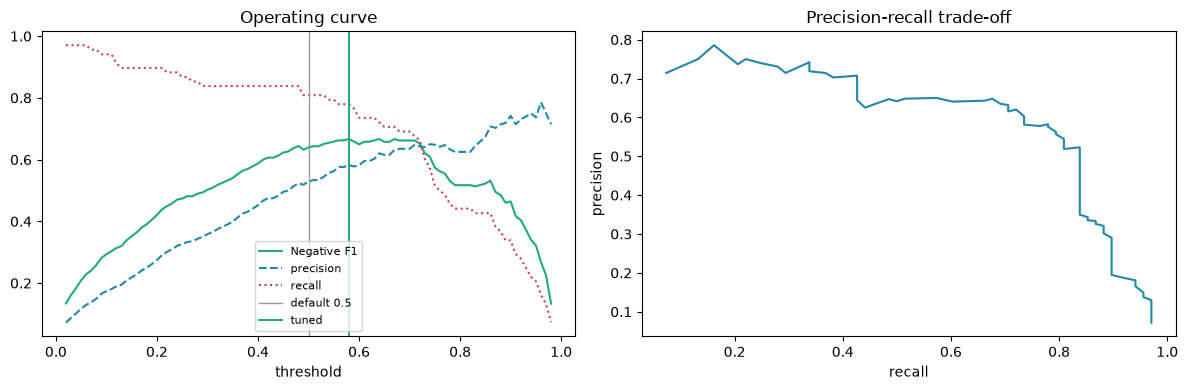

In [5]:
tuned = sb.tuning.tune_threshold(champ["_estimator"], dev_si.text, dev_si.sentiment,
                                 "sentiment")
print(f"default 0.50 -> negative_f1 {tuned['default_threshold_negative_f1']:.4f}")
print(f"tuned  {tuned['threshold']:.2f} -> negative_f1 {tuned['negative_f1']:.4f}  "
      f"({tuned['gain_over_default']:+.4f})")

curve = tuned["curve"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(curve.threshold, curve.negative_f1, label="Negative F1", color="#2a7")
ax[0].plot(curve.threshold, curve.negative_precision, label="precision", ls="--", color="#28a")
ax[0].plot(curve.threshold, curve.negative_recall, label="recall", ls=":", color="#c44")
ax[0].axvline(0.5, color="#999", lw=1, label="default 0.5")
ax[0].axvline(tuned["threshold"], color="#2a7", lw=1.4, label="tuned")
ax[0].set_xlabel("threshold"); ax[0].set_title("Operating curve"); ax[0].legend(fontsize=8)

ax[1].plot(curve.negative_recall, curve.negative_precision, color="#28a")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[1].set_title("Precision-recall trade-off")
plt.tight_layout(); plt.show()

### The operating point is a product decision, not an ML one

Escalation cares about *not missing angry customers*. Buying recall costs
precision fast, and how much false-escalation the agents will absorb is a
question for the product owner, not the model.

In [6]:
rows = []
for target in [None, 0.80, 0.85, 0.90, 0.95]:
    try:
        t = sb.tuning.tune_threshold(champ["_estimator"], dev_si.text, dev_si.sentiment,
                                     "sentiment", min_recall=target)
        rows.append({"policy": "max F1" if target is None else f"recall >= {target:.2f}",
                     "threshold": t["threshold"], "negative_f1": t["negative_f1"],
                     "precision": t["negative_precision"], "recall": t["negative_recall"]})
    except ValueError as exc:
        rows.append({"policy": f"recall >= {target:.2f}", "threshold": None,
                     "negative_f1": None, "precision": None, "recall": str(exc)[:30]})

display(pd.DataFrame(rows).round(4))
print("\nAt 95% recall, ~3 in 4 escalations are false alarms.")
print("Someone has to decide whether that is acceptable.")

,policy,threshold,negative_f1,precision,recall
0,max F1,0.58,0.6667,0.5824,0.7794
1,recall >= 0.80,0.53,0.6509,0.5446,0.8088
2,recall >= 0.85,0.28,0.4895,0.3432,0.8529
3,recall >= 0.90,0.12,0.3139,0.1896,0.9118
4,recall >= 0.95,0.08,0.2584,0.1494,0.9559



At 95% recall, ~3 in 4 escalations are false alarms.
Someone has to decide whether that is acceptable.


## 4. Hyperparameter search — `C` was never tuned

Scored with cross-validation, not the single dev split.

tfidf-logreg  C=0.1   negative_f1 0.4232 +/- 0.0207


tfidf-logreg  C=0.5   negative_f1 0.4982 +/- 0.0359


tfidf-logreg  C=1.0   negative_f1 0.5286 +/- 0.0381


tfidf-logreg  C=3.0   negative_f1 0.5502 +/- 0.0371


tfidf-logreg  C=10.0  negative_f1 0.5459 +/- 0.0415


tfidf-svm     C=0.1   negative_f1 0.5403 +/- 0.0328


tfidf-svm     C=0.5   negative_f1 0.5525 +/- 0.0444


tfidf-svm     C=1.0   negative_f1 0.5508 +/- 0.0383


tfidf-svm     C=3.0   negative_f1 0.5061 +/- 0.0435


tfidf-svm     C=10.0  negative_f1 0.4734 +/- 0.0536

best: tfidf-svm C=0.5 -> 0.5525
Compare against the pinned C=1.0 rows to see whether tuning was worth it.


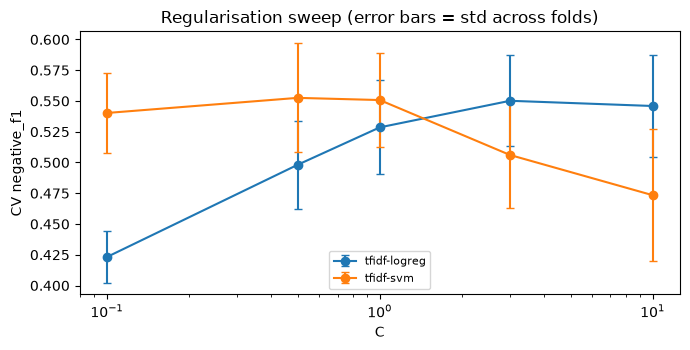

In [7]:
grid = []
for model in ["tfidf-logreg", "tfidf-svm"]:
    for C in [0.1, 0.5, 1.0, 3.0, 10.0]:
        cv = sb.tuning.cross_validate("sentiment", model, ["singlish"], arm="class_weight",
                                      C=C, n_splits=5)
        s = sb.tuning.summarise_cv(cv)
        grid.append({"model": model, "C": C, "mean": s["mean_headline"],
                     "std": s["std_headline"]})
        print(f"{model:13s} C={C:<5} negative_f1 {s['mean_headline']:.4f} +/- {s['std_headline']:.4f}")

grid_df = pd.DataFrame(grid)
best = grid_df.loc[grid_df["mean"].idxmax()]
print(f"\nbest: {best.model} C={best.C} -> {best['mean']:.4f}")
print("Compare against the pinned C=1.0 rows to see whether tuning was worth it.")

fig, ax = plt.subplots(figsize=(7, 3.6))
for model, g in grid_df.groupby("model"):
    ax.errorbar(g.C, g["mean"], yerr=g["std"], marker="o", capsize=3, label=model)
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("CV negative_f1")
ax.set_title("Regularisation sweep (error bars = std across folds)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 5. Combined best classical setup

Everything above applied together, then measured with an honest CI.

In [8]:
final = sb.tuning.cross_validate("sentiment", best.model, ["singlish"],
                                 arm="class_weight", C=float(best.C),
                                 n_splits=5, tune_thresholds=True)
s = sb.tuning.summarise_cv(final)

bakeoff_headline = bake.negative_f1.max()
print(f"bake-off headline (single dev split, C=1.0, thr=0.5) : {bakeoff_headline:.4f}")
print(f"CV, tuned C, default threshold                       : {s['mean_headline']:.4f} +/- {s['std_headline']:.4f}")
print(f"CV, tuned C, tuned threshold                         : {s['mean_tuned_headline']:.4f}")
print()
print("The bake-off number is the maximum of 168 draws from a noisy distribution.")
print("The CV number is what to expect on unseen data. Expect the CV one to be lower —")
print("that gap is the selection optimism, not a regression.")

pd.DataFrame([{"setup": "bake-off max (optimistic)", "negative_f1": bakeoff_headline},
              {"setup": "CV tuned C", "negative_f1": s["mean_headline"]},
              {"setup": "CV tuned C + tuned threshold", "negative_f1": s["mean_tuned_headline"]}]
             ).round(4).to_csv(REPO / "ml" / "reports" / "sentiment_corrected_dev.csv", index=False)
display(pd.read_csv(REPO / "ml" / "reports" / "sentiment_corrected_dev.csv"))

bake-off headline (single dev split, C=1.0, thr=0.5) : 0.6395
CV, tuned C, default threshold                       : 0.5525 +/- 0.0444
CV, tuned C, tuned threshold                         : 0.5721

The bake-off number is the maximum of 168 draws from a noisy distribution.
The CV number is what to expect on unseen data. Expect the CV one to be lower —
that gap is the selection optimism, not a regression.


,setup,negative_f1
0,bake-off max (optimistic),0.6395
1,CV tuned C,0.5525
2,CV tuned C + tuned threshold,0.5721


## Read-out

- The bake-off champion's CI is ~0.17 wide on 68 Negative tickets. Model ranking
  within that band is not measurable with this dev set.
- Threshold tuning is worth more than most model choices and costs nothing.
- **The binding constraint is 462 Negative training examples, not model choice.**
  Every improvement here is second-order next to labelling more Negatives or
  augmenting them.

Next: `07_encoder_bakeoff.ipynb` tests whether a pretrained encoder brings
knowledge those 462 examples cannot.